# Batch correction with totalVI (joint RNA + protein)

totalVI (Gayoso et al., *Nat Methods* 2021) is scvi-tools' joint generative model for CITE-seq / Total-seq data. It learns a shared latent space across RNA and ADT while explicitly modelling protein background, and corrects batch effects in both modalities. This demo synthesises an ADT matrix — on real data, populate `adata.obsm['protein_counts']` with your `(cell × protein)` raw ADT counts before the call.

This is one of the **omicverse batch-correction zoo** tutorials. See [batch/index](../index.md) for the overview / decision tree, or [../t_single_batch](../t_single_batch.ipynb) for the side-by-side comparison of every backend on a real benchmark.

## Load a real CITE-seq 2-batch dataset

We use `scvi.data.pbmcs_10x_cite_seq` — a Stoeckius-style 10x
PBMC CITE-seq dataset bundled with scvi-tools, 10 849 cells across
two real donor batches (PBMC10k + PBMC5k), 15 792 genes in `.X`
and 14 surface proteins in `obsm['protein_expression']`. The NeurIPS
2021 multimodal hematopoiesis dataset used by the other zoo
notebooks ships GEX-only on figshare, so for totalVI — which needs
*real* protein counts — we switch to this self-contained CITE-seq
demo. The pipeline is otherwise identical to the rest of the zoo.


In [1]:
import omicverse as ov
ov.style()
import anndata as ad
import numpy as np
import pandas as pd
import scvi.data as scvi_data
import os

# Real 10x PBMC CITE-seq — 2 batches, 15 792 genes, 14 ADT proteins
# in `obsm['protein_expression']`. Cached under ./data/scvi_cache so
# subsequent re-renders hit local disk.
os.makedirs('./data/scvi_cache', exist_ok=True)
adata = scvi_data.pbmcs_10x_cite_seq(save_path='./data/scvi_cache')
adata.obs_names_make_unique()
adata.var_names_make_unique()
adata.obs['batch'] = adata.obs['batch'].astype('category')

# Subsample to ~6 000 cells so the whole notebook stays GPU-snappy.
_rng = np.random.default_rng(0)
_sel = _rng.choice(adata.n_obs, 6000, replace=False)
adata = adata[_sel].copy()

# totalVI needs raw counts: layers['counts'] for genes + the protein
# matrix already lives in obsm['protein_expression'].
adata.layers['counts'] = adata.X.copy()
print(adata)
print('protein_expression shape:', adata.obsm['protein_expression'].shape)


/scratch/users/steorra/env/omicdev/lib/python3.10/site-packages/requests/__init__.py:86: RequestsDependencyWarning: Unable to find acceptable character detection dependency (chardet or charset_normalizer).
  warnings.warn(
/scratch/users/steorra/env/omicdev/lib/python3.10/site-packages/anndata/utils.py:434: FutureWarning: Importing read_loom from `anndata` is deprecated. Import anndata.io.read_loom instead.
  warnings.warn(msg, FutureWarning)


/scratch/users/steorra/env/omicdev/lib/python3.10/site-packages/louvain/__init__.py:54: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import get_distribution, DistributionNotFound


🔬 Starting plot initialization...
🧬 Detecting GPU devices…
✅ NVIDIA CUDA GPUs detected: 1
    • [CUDA 0] NVIDIA H100 80GB HBM3
      Memory: 79.1 GB | Compute: 9.0

   ____            _     _    __                  
  / __ \____ ___  (_)___| |  / /__  _____________ 
 / / / / __ `__ \/ / ___/ | / / _ \/ ___/ ___/ _ \ 
/ /_/ / / / / / / / /__ | |/ /  __/ /  (__  )  __/ 
\____/_/ /_/ /_/_/\___/ |___/\___/_/  /____/\___/                                              

🔖 Version: 2.2.1rc1   📚 Tutorials: https://omicverse.readthedocs.io/
✅ plot_set complete.



INFO     File ./data/scvi_cache/pbmc_10k_protein_v3.h5ad already downloaded                                        


INFO     File ./data/scvi_cache/pbmc_5k_protein_v3.h5ad already downloaded                                         


AnnData object with n_obs × n_vars = 6000 × 15792
    obs: 'n_genes', 'percent_mito', 'n_counts', 'batch'
    obsm: 'protein_expression'
    layers: 'counts'
protein_expression shape: (6000, 14)


## Preprocess + PCA + cluster

Same QC → HVG-via-pearson → log-norm → PCA pipeline shared across
every backend in the zoo. The pbmcs_10x_cite_seq dataset ships
without pre-annotated cell types, so we run a quick Leiden clustering
on the PCA neighbours graph for `celltype` colouring on the
uncorrected / corrected UMAP — the labels are for visualisation, not
input to totalVI.


In [2]:
# Standard omicverse preprocess (QC → HVG-via-pearson → log-norm → PCA).
adata = ov.pp.qc(adata, tresh={'mito_perc': 0.2, 'nUMIs': 200,
                                 'detected_genes': 100})
# layers['counts'] was set above to preserve the raw matrix; preprocess
# operates on .X, so it's safe to log-normalise and HVG-select here.
adata = ov.pp.preprocess(adata, mode='shiftlog|pearson', n_HVGs=2000,
                         batch_key=None)
adata.raw = adata
adata = adata[:, adata.var.highly_variable_features].copy()
ov.pp.scale(adata)
ov.pp.pca(adata, layer='scaled', n_pcs=30)
ov.pp.neighbors(adata, use_rep='scaled|original|X_pca', n_neighbors=15)

# Quick Leiden cluster as `celltype` for colour-only purposes —
# pbmcs_10x_cite_seq ships without pre-annotation. totalVI itself
# does not see these labels.
ov.pp.leiden(adata, resolution=0.5, key_added='celltype')
adata.obs['celltype'] = adata.obs['celltype'].astype('category')
adata


🖥️ Using CPU mode for QC...
   Auto-detected mitochondrial prefix: 'MT-'

📊 Step 1: Calculating QC Metrics

   ✓ Gene Family Detection:
   ┌──────────────────────────────┬────────────────────┬────────────────────┐
   │ Gene Family                  │ Genes Found        │ Detection Method   │
   ├──────────────────────────────┼────────────────────┼────────────────────┤
   │ Mitochondrial                │ 13                 │ Auto (MT-)         │
   ├──────────────────────────────┼────────────────────┼────────────────────┤
   │ Ribosomal                    │ 95                 │ Auto (RPS/RPL)     │
   ├──────────────────────────────┼────────────────────┼────────────────────┤
   │ Hemoglobin                   │ 6                  │ Auto (regex)       │
   └──────────────────────────────┴────────────────────┴────────────────────┘

   ✓ QC Metrics Summary:
   ┌─────────────────────────┬────────────────────┬─────────────────────────┐
   │ Metric                  │ Mean               │ Range 

   ✓ Final filtering: 0 cells, 11 genes removed

🔍 Step 4: Doublet Detection
   💡 Running pyscdblfinder (Python port of R scDblFinder)
   🔍 Running scdblfinder detection...


[ScDblFinder] wrote scDblFinder_score + scDblFinder_class — threshold=0.060
   ✓ scDblFinder completed: 178 doublets removed (3.0%)



╭─ SUMMARY: qc ──────────────────────────────────────────────────────╮
│  Duration: 30.6914s                                                │
│  Shape:    6,000 x 15,792 (Unchanged)                              │
│                                                                    │
│  CHANGES DETECTED                                                  │
│  ────────────────                                                  │
│  ● OBS    │ ✚ cell_complexity (float)                              │
│           │ ✚ detected_genes (int)                                 │
│           │ ✚ hb_perc (float)                                      │
│           │ ✚ mito_perc (float)                                    │
│           │ ✚ nUMIs (float)                                        │
│           │ ✚ n_genes_by_counts (int)                              │
│           │ ✚ passing_mt (bool)                                    │
│           │ ✚ passing_nUMIs (bool)                                 │
│    

🔍 [2026-05-29 05:09:14] Running preprocessing in 'cpu' mode...
Begin robust gene identification
    After filtration, 15781/15781 genes are kept.
    Among 15781 genes, 15781 genes are robust.
✅ Robust gene identification completed successfully.
Begin size normalization: shiftlog and HVGs selection pearson


...


✅ Experimental HVG Selection Completed Successfully!
   ✓ Selected: 2,000 highly variable genes out of 15,781 total (12.7%)
   ✓ Results added to AnnData object:
     • 'highly_variable': Boolean vector (adata.var)
     • 'highly_variable_rank': Float vector (adata.var)
     • 'highly_variable_nbatches': Int vector (adata.var)
     • 'highly_variable_intersection': Boolean vector (adata.var)
     • 'means': Float vector (adata.var)
     • 'variances': Float vector (adata.var)
     • 'residual_variances': Float vector (adata.var)
    Time to analyze data in cpu: 7.22 seconds.
✅ Preprocessing completed successfully.
    Added:
        'highly_variable_features', boolean vector (adata.var)
        'means', float vector (adata.var)
        'variances', float vector (adata.var)
        'residual_variances', float vector (adata.var)
        'counts', raw counts layer (adata.layers)
    End of size normalization: shiftlog and HVGs selection pearson

╭─ SUMMARY: preprocess ───────────────────


╭─ SUMMARY: scale ───────────────────────────────────────────────────╮
│  Duration: 0.3267s                                                 │
│  Shape:    5,821 x 2,000 (Unchanged)                               │
│                                                                    │
│  CHANGES DETECTED                                                  │
│  ────────────────                                                  │
│  ● LAYERS │ ✚ scaled (array, 5821x2000)                            │
│                                                                    │
╰────────────────────────────────────────────────────────────────────╯
computing PCA🔍
    with n_comps=30
   🖥️ Using sklearn PCA for CPU computation
   🖥️ sklearn PCA backend: CPU computation
   📊 PCA input data type: ArrayView, shape: (5821, 2000), dtype: float32


   🔧 PCA solver used: covariance_eigh
    finished✅ (1.18s)

╭─ SUMMARY: pca ─────────────────────────────────────────────────────╮
│  Duration: 1.1866s                                                 │
│  Shape:    5,821 x 2,000 (Unchanged)                               │
│                                                                    │
│  CHANGES DETECTED                                                  │
│  ────────────────                                                  │
│  ● UNS    │ ✚ pca                                                  │
│           │ └─ params: {'zero_center': True, 'use_highly_variable': Tr...│
│           │ ✚ scaled|original|cum_sum_eigenvalues                  │
│           │ ✚ scaled|original|pca_var_ratios                       │
│                                                                    │
│  ● OBSM   │ ✚ X_pca (array, 5821x30)                               │
│           │ ✚ scaled|original|X_pca (array, 5821x30)               │
│         

   ✓ Graph is fully connected

✅ KNN Graph Construction Completed Successfully!
   ✓ Processed: 5,821 cells with 15 neighbors each
   ✓ Results added to AnnData object:
     • 'neighbors': Neighbors metadata (adata.uns)
     • 'distances': Distance matrix (adata.obsp)
     • 'connectivities': Connectivity matrix (adata.obsp)

╭─ SUMMARY: neighbors ───────────────────────────────────────────────╮
│  Duration: 8.0982s                                                 │
│  Shape:    5,821 x 2,000 (Unchanged)                               │
│                                                                    │
│  CHANGES DETECTED                                                  │
│  ────────────────                                                  │
│  ● UNS    │ ✚ neighbors                                            │
│           │ └─ params: {'n_neighbors': 15, 'method': 'umap', 'random_s...│
│                                                                    │
│  ● OBSP   │ ✚ connectivit

AnnData object with n_obs × n_vars = 5821 × 2000
    obs: 'n_genes', 'percent_mito', 'n_counts', 'batch', 'nUMIs', 'mito_perc', 'ribo_perc', 'hb_perc', 'detected_genes', 'cell_complexity', 'total_counts', 'n_genes_by_counts', 'pct_counts_mt', 'pct_counts_ribo', 'pct_counts_hb', 'passing_mt', 'passing_nUMIs', 'passing_ngenes', 'predicted_doublet', 'doublet_score', 'scdblfinder_doublet', 'scdblfinder_score', 'celltype', 'leiden'
    var: 'mt', 'ribo', 'hb', 'robust', 'highly_variable_features', 'means', 'variances', 'residual_variances', 'highly_variable_rank', 'highly_variable'
    uns: 'status', 'status_args', 'REFERENCE_MANU', '_ov_provenance', 'history_log', 'log1p', 'hvg', 'pca', 'scaled|original|pca_var_ratios', 'scaled|original|cum_sum_eigenvalues', 'neighbors', 'celltype'
    obsm: 'protein_expression', 'X_pca', 'scaled|original|X_pca'
    varm: 'PCs', 'scaled|original|pca_loadings'
    layers: 'counts', 'scaled'
    obsp: 'distances', 'connectivities'

## Uncorrected baseline

The planted batch effect is visible in the uncorrected UMAP:

🔍 [2026-05-29 05:09:32] Running UMAP in 'cpu' mode...
🖥️ Using Scanpy CPU UMAP...



🔍 UMAP Dimensionality Reduction:
   Mode: cpu
   Method: umap
   Components: 2
   Min distance: 0.3
{'n_neighbors': 15, 'method': 'umap', 'random_state': 0, 'metric': 'euclidean', 'use_rep': 'scaled|original|X_pca'}
   🔍 Computing UMAP parameters...
   🔍 Computing UMAP embedding (classic method)...



✅ UMAP Dimensionality Reduction Completed Successfully!
   ✓ Embedding shape: 5,821 cells × 2 dimensions
   ✓ Results added to AnnData object:
     • 'X_umap': UMAP coordinates (adata.obsm)
     • 'umap': UMAP parameters (adata.uns)
✅ UMAP completed successfully.

╭─ SUMMARY: umap ────────────────────────────────────────────────────╮
│  Duration: 0.9007s                                                 │
│  Shape:    5,821 x 2,000 (Unchanged)                               │
│                                                                    │
│  CHANGES DETECTED                                                  │
│  ────────────────                                                  │
│  ● UNS    │ ✚ umap                                                 │
│           │ └─ params: {'a': np.float64(0.9921756195894755), 'b': np.f...│
│                                                                    │
│  ● OBSM   │ ✚ X_umap (array, 5821x2)                               │
│                 

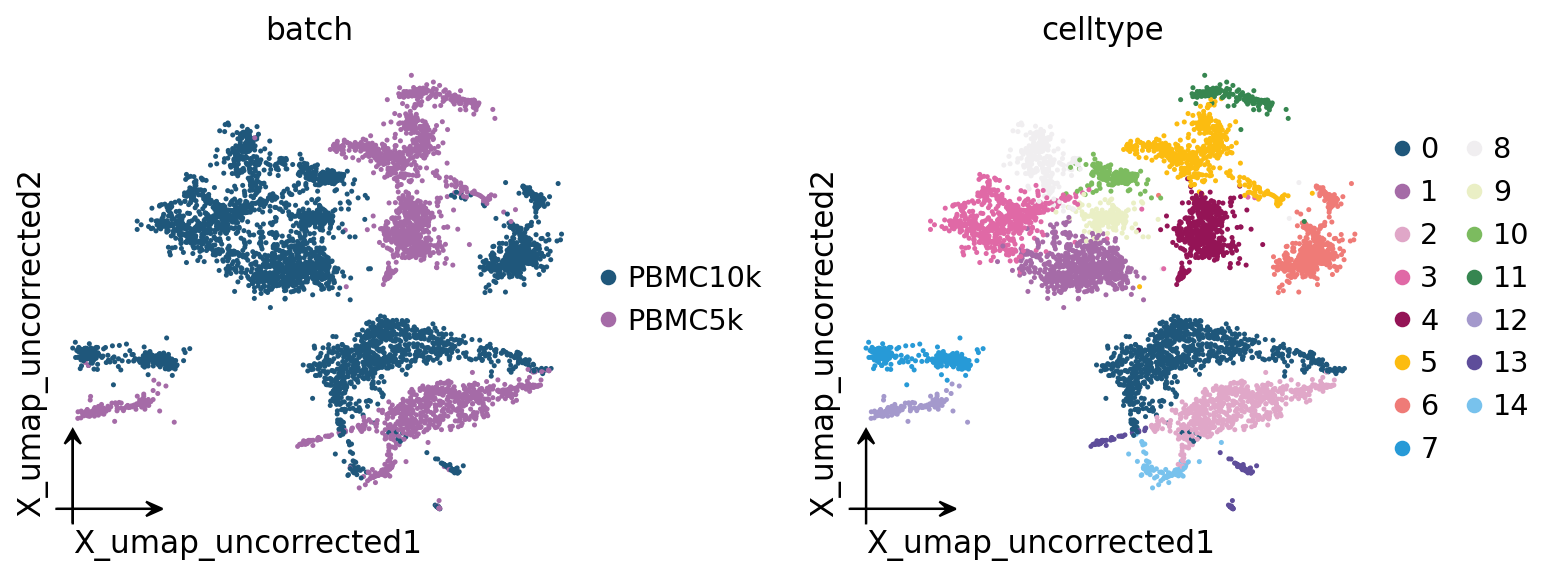

In [3]:
# Pre-correction UMAP shows the planted batch effect.
ov.pp.umap(adata, min_dist=0.3)
adata.obsm['X_umap_uncorrected'] = adata.obsm['X_umap'].copy()
ov.pl.embedding(adata, basis='X_umap_uncorrected',
                color=['batch', 'celltype'],
                frameon='small', wspace=0.5)

## Run `ov.single.batch_correction(methods='totalVI')`

totalVI needs raw RNA counts in `layers['counts']` and a raw protein
matrix in an `obsm` slot whose name is passed via
`protein_expression_obsm_key`. The wrapper auto-routes the remaining
`**kwargs` between `TOTALVI.__init__` (architecture) and
`.train()` (optimisation).


In [4]:
model = ov.single.batch_correction(
    adata,
    batch_key='batch',
    methods='totalVI',
    # Required: name of the obsm slot holding the raw protein matrix.
    protein_expression_obsm_key='protein_expression',
    # All architecture + training kwargs left at scvi-tools defaults.
)
model


...Begin using totalVI to correct batch effect
INFO     Using column names from columns of adata.obsm['protein_expression']                                       


INFO     Computing empirical prior initialization for protein background.                                          


GPU available: True (cuda), used: True


TPU available: False, using: 0 TPU cores


HPU available: False, using: 0 HPUs


...

LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Training:   0%|          | 0/400 [00:00<?, ?it/s]

`Trainer.fit` stopped: `max_epochs=400` reached.



╭─ SUMMARY: batch_correction ────────────────────────────────────────╮
│  Duration: 92.9711s                                                │
│  Shape:    5,821 x 2,000 (Unchanged)                               │
│                                                                    │
│  CHANGES DETECTED                                                  │
│  ────────────────                                                  │
│  ● OBS    │ ✚ _scvi_batch (int)                                    │
│           │ ✚ _scvi_labels (int)                                   │
│                                                                    │
│  ● UNS    │ ✚ _scvi_manager_uuid                                   │
│           │ ✚ _scvi_uuid                                           │
│                                                                    │
│  ● OBSM   │ ✚ X_totalVI (array, 5821x20)                           │
│                                                                    │
╰────

TotalVI Model with the following params: 
n_latent: 20, gene_dispersion: gene, protein_dispersion: protein, gene_likelihood: nb, latent_distribution: normal
Training status: Trained
Model's adata is minified?: False
Model's adata is minified?: False

## Corrected embedding

Every backend writes its corrected representation to a stable obsm key — for this one it is `adata.obsm['X_totalVI']`. We project via `ov.utils.mde` for a lightweight UMAP-style display.

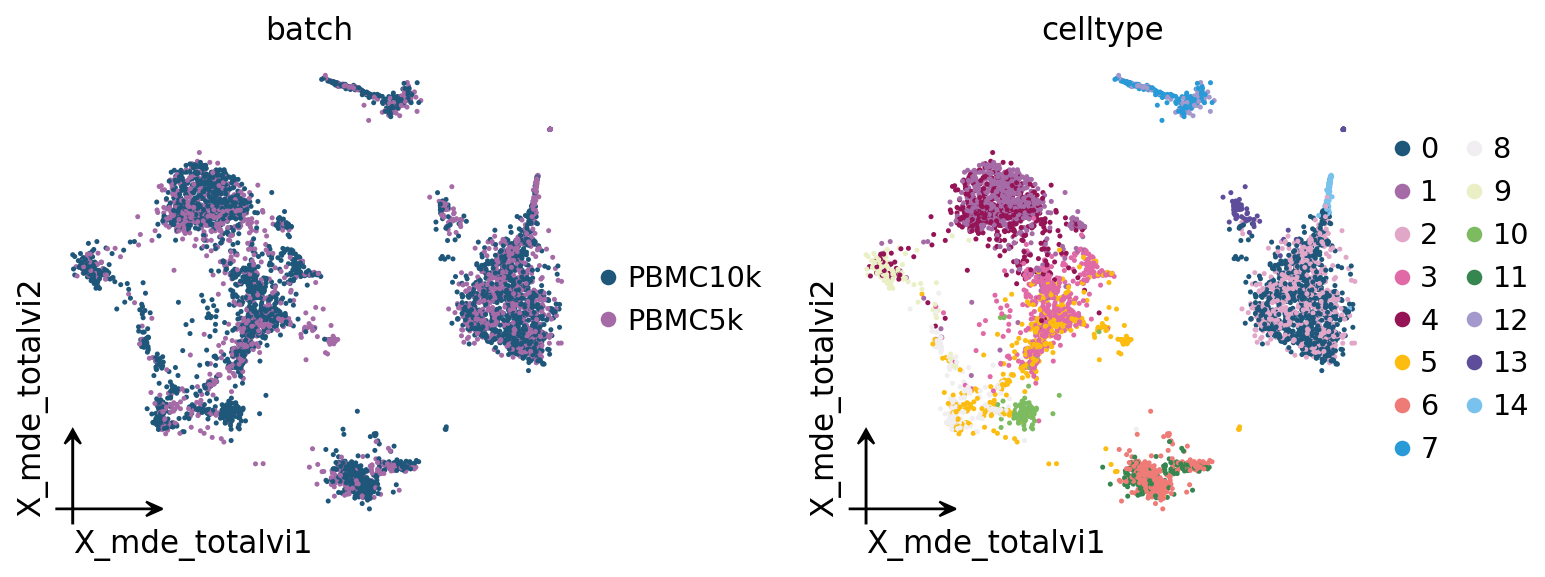

In [5]:
adata.obsm['X_mde_totalvi'] = ov.utils.mde(adata.obsm['X_totalVI'])
ov.pl.embedding(
    adata,
    basis='X_mde_totalvi',
    color=['batch', 'celltype'],
    frameon='small',
    wspace=0.5,
)

## Key parameters

**Required**:
- `protein_expression_obsm_key` — name of the obsm slot with the protein matrix.

**Architecture** (→ `scvi.model.TOTALVI.__init__`):
- `n_latent`, `gene_dispersion`, `protein_dispersion`, `gene_likelihood`, `latent_distribution`.

**Optimisation** (→ `scvi.model.TOTALVI.train`):
- `max_epochs`, `batch_size`, `early_stopping`, `accelerator`.


## Related tutorials

- [t_batch_scvi](t_batch_scvi.ipynb) — RNA-only.
- [t_batch_scanvi](t_batch_scanvi.ipynb) — RNA + labels.

For the full side-by-side comparison with scib-metrics scoring, see [../t_single_batch](../t_single_batch.ipynb).